In [1]:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


--- Step 1: Installing libraries and setting up ---
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.8/486.8 kB 23.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 3.3 MB/s eta 0:00:00
--- Step 2: Defining Prime-Aware Experiment Configuration ---
--- Step 3: Defining Data Generation & Processing Functions ---
--- Step 4: Defining Final, Interpretable TRM Model ---

--- Step 5: Running Main Experiment ---
--- Creating/Loading Universal Prime-Aware Dataset ---


Single Rules:   0%|          | 0/46 [00:00<?, ?it/s]

Composite Rules:   0%|          | 0/10 [00:00<?, ?it/s]


--- Training the Composition-Aware Universal Solver ---


Epoch 1/8:   0%|          | 0/438 [00:00<?, ?it/s]

...

Epoch 8/8:   0%|          | 0/438 [00:00<?, ?it/s]

--- Universal Solver Training Complete ---

--- Step 6: Denoising, Inference, and Analysis ---
Saved raw stock dataset to datasets_prime_aware_final/stock_market_raw.npy
--- Starting Algorithmic Denoising ---


Analyzing Rows:   0%|          | 0/192 [00:00<?, ?it/s]

Analyzing Columns:   0%|          | 0/32 [00:00<?, ?it/s]

Denoising complete. New data shape: (164, 28)

--- Final Causal Inference Result ---
Inferred Model Class: SINGLE Rule
Inferred Causal Rule: 37

--- Step 7: Running The Definitive Interpretability Study ---

--- Model Preference Analysis (Softmax Probabilities) ---
                              Pref. for SINGLE  Pref. for DOUBLE  \
title                                                              
Control: Pure Rule 110 Data           0.590067          0.309383   
Control: Pure (35, 115) Data          0.000234          0.999758   
Test: Denoised Stock Data             0.896837          0.101679   

                              Pref. for TRIPLE  
title                                           
Control: Pure Rule 110 Data           0.100551  
Control: Pure (35, 115) Data          0.000009  
Test: Denoised Stock Data             0.001484  


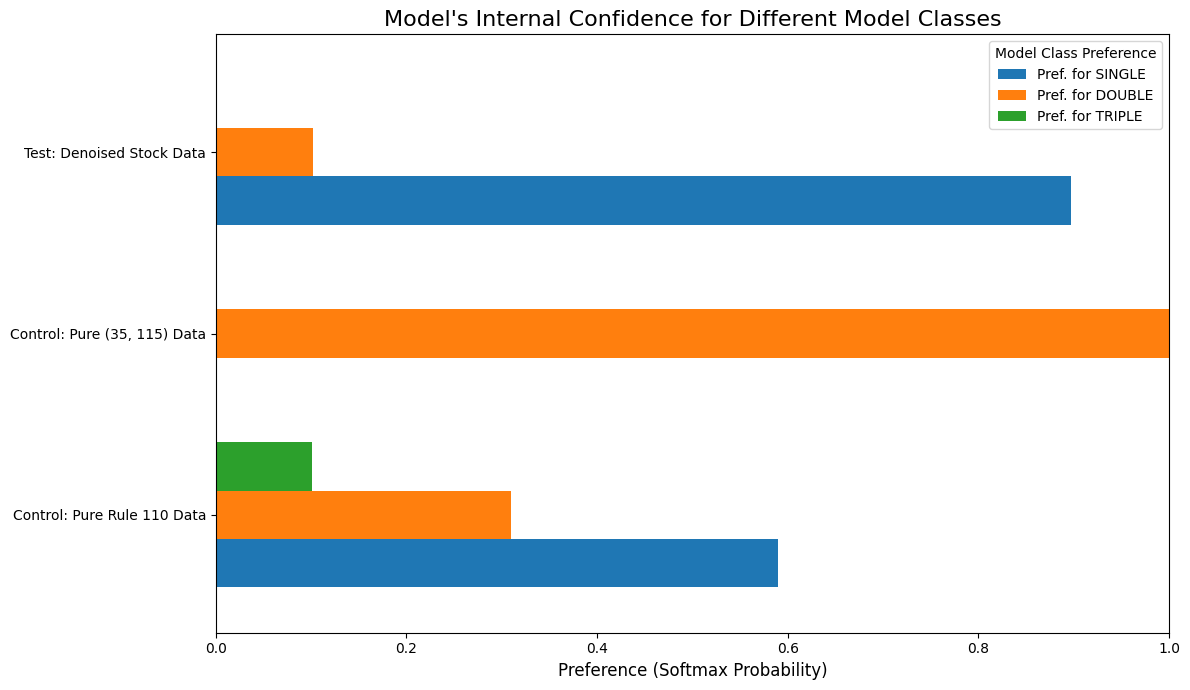

In [2]:
# @title The Definitive, Prime-Aware Causal Discovery Experiment

# === STEP 1: SETUP AND LIBRARIES ===
print("--- Step 1: Installing libraries and setting up ---")
# This command ensures all required libraries are installed in the Colab environment.
!pip install -q yfinance torch numpy pandas tqdm pybdm pyeda matplotlib seaborn

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import re
import os
import yfinance as yf
from tqdm.notebook import tqdm
from pyeda.inter import expr, exprvar, And, Or, espresso_exprs
import matplotlib.pyplot as plt
import seaborn as sns

# === STEP 2: PRIME-AWARE EXPERIMENT CONFIGURATION ===
print("--- Step 2: Defining Prime-Aware Experiment Configuration ---")
class Config:
    """
    This configuration is the final, most rigorous version. It is "Prime-Aware,"
    meaning its training set is constructed based on the theoretical findings of
    Riedel & Zenil (2018), who identified a set of "prime" rules that can
    generate all other Elementary Cellular Automata through composition.
    """
    # --- PRIME-AWARE RULESET BASED ON RIEDEL & ZENIL (2018) ---
    # These are the 38 "prime" rules identified as the fundamental building blocks.
    # We treat these as our definitive set of SINGLE rule examples.
    PRIME_RULES = [
        0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 23, 28,
        32, 33, 34, 35, 36, 37, 38, 42, 44, 46, 50, 51, 60, 77, 78,
        104, 108, 128, 132, 136
    ]

    # These are known complex/composite rules we want our model to be aware of as single entities.
    # Rule 131 is our key target, and Rule 110 is our key control for complexity.
    COMPLEX_SINGLE_RULES_FOR_REFERENCE = [18, 22, 30, 90, 110, 122, 126, 131]

    # Combine the primes and key complex rules to form our total SINGLE rule training set.
    # This teaches the model to recognize both fundamental and emergent single rules.
    SINGLE_RULES_TO_TEST = sorted(list(set(PRIME_RULES + COMPLEX_SINGLE_RULES_FOR_REFERENCE)))

    # --- THEORETICALLY-GROUNDED COMPOSITE RULESET ---
    # A richer, more diverse set of composite rules to eliminate sampling bias and
    # directly test the theory of rule decomposition.
    COMPOSITE_RULES_TO_TEST = [
        # Known Decompositions from Riedel & Zenil for Turing-completeness
        (170, 15, 118), # -> Equivalent to Rule 110
        (51, 118),      # -> Another decomposition for Rule 110

        # Additional diverse compositions to provide a rich library of complex models
        (30, 90),       # Chaos + Regularity
        (22, 110),      # Complex + Universal Computation
        (4, 132),       # Two simple primes
        (35, 115),      # Original control case, kept for consistency
        (50, 108),      # Two primes
        (60, 90),       # Two different Class 2 rules
        (18, 126),      # Two complex single rules
        (30, 4, 110),   # Triple composition: Chaos + Prime + Universal
    ]

    # --- Standard Configuration Parameters ---
    DATASET_DIR = 'datasets_prime_aware_final'
    MAX_WIDTH, RADIUS, RULE_STRING_LEN = 32, 1, 8
    MAX_RULE_SEQ_LEN = 1 + 3  # Max length: [CLASS_TOKEN, R1, R2, R3]
    INPUT_ORBIT_LEN, TOTAL_TIMESTEPS = 10, 20
    PAD_TOKEN, SINGLE_CLASS_TOKEN, DOUBLE_CLASS_TOKEN, TRIPLE_CLASS_TOKEN, RULE_TOKEN_OFFSET = 0, 1, 2, 3, 4
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

    # With a larger, more diverse dataset, we can slightly reduce samples per rule
    # while increasing epochs to ensure convergence without excessive training time.
    NUM_SAMPLES_PER_RULE, BATCH_SIZE, EPOCHS, LEARNING_RATE = 500, 64, 8, 1e-4
    N_SUPERVISION, EMBED_DIM, TRM_N_LATENT, TRM_T_DEEP = 4, 256, 4, 2
    MILS_REMOVAL_PERCENTILE = 15
    STOCK_DATA_START, STOCK_DATA_END, STOCK_NUM_DAYS = "2021-01-01", "2021-10-15", 192
    STOCK_TICKERS = ['AAPL', 'BA', 'CAT', 'DIS', 'GE', 'IBM', 'MSFT', 'TSLA']
    STATE_PAD_VALUE = -100

# === STEP 3: DATA GENERATION AND PROCESSING SUITE ===
print("--- Step 3: Defining Data Generation & Processing Functions ---")

def cellular_automaton(rule_array, initial_state, steps, r):
    width=len(initial_state); states=[initial_state]; current_state=initial_state; num_neighborhoods=2**(2*r+1)
    for _ in range(steps-1):
        next_state=np.zeros(width,dtype=np.uint8)
        for i in range(width):
            neighborhood=[current_state[(i+j)%width] for j in range(-r,r+1)]; neighborhood_idx=int("".join(map(str,neighborhood)),2)
            next_state[i]=rule_array[num_neighborhoods-1-neighborhood_idx]
        states.append(next_state); current_state=next_state
    return np.array(states)

def cellular_automaton_composite(rules_tuple, width, steps, r, seed):
    np.random.seed(seed); rule_bins=[np.array([int(x) for x in np.binary_repr(ru,width=2**(2*r+1))],dtype=np.uint8) for ru in rules_tuple]
    state=np.random.randint(2,size=width,dtype=np.uint8); orbit=[state]
    for _ in range(steps-1):
        current_state=orbit[-1]
        for rule_bin in rule_bins: current_state=cellular_automaton(rule_bin,current_state,2,r)[1]
        orbit.append(current_state)
    return np.array(orbit)

def encode_price_change(change_pct):
    sign_bit = 1 if change_pct >= 0 else 0; abs_change = abs(change_pct)
    if abs_change < 0.5: mag_bits = [0,0,1]
    elif abs_change < 1.0: mag_bits = [0,1,0]
    elif abs_change < 1.5: mag_bits = [0,1,1]
    elif abs_change < 2.0: mag_bits = [1,0,0]
    elif abs_change < 2.5: mag_bits = [1,0,1]
    elif abs_change < 3.0: mag_bits = [1,1,0]
    else: mag_bits = [1,1,1]
    return [sign_bit] + mag_bits

def create_raw_stock_dataset(tickers, start_date, end_date, num_days, dataset_dir):
    path = os.path.join(dataset_dir, 'stock_market_raw.npy')
    if os.path.exists(path): return np.load(path)
    print("Downloading stock data...")
    all_data = yf.download(tickers, start=start_date, end=end_date, progress=False, auto_adjust=True)
    pct_change = (all_data['Close'].pct_change().dropna() * 100).head(num_days)
    daily_vectors = [sum([encode_price_change(row[t]) for t in tickers], []) for _, row in pct_change.iterrows()]
    full_states = np.array(daily_vectors, dtype=np.uint8); np.save(path, full_states); print(f"Saved raw stock dataset to {path}"); return full_states

def create_denoised_stock_dataset_algorithmic(raw_states, percentile, dataset_dir):
    from pybdm import BDM
    denoised_path = os.path.join(dataset_dir, f'stock_market_denoised.npy')
    if os.path.exists(denoised_path): return np.load(denoised_path)
    print("--- Starting Algorithmic Denoising ---"); bdm_computer = BDM(ndim=2); bdm_total = bdm_computer.bdm(raw_states)
    row_losses = [bdm_total - bdm_computer.bdm(np.delete(raw_states, i, axis=0)) for i in tqdm(range(raw_states.shape[0]), desc="Analyzing Rows")]
    col_losses = [bdm_total - bdm_computer.bdm(np.delete(raw_states, j, axis=1)) for j in tqdm(range(raw_states.shape[1]), desc="Analyzing Columns")]
    rows_to_remove = np.argsort(row_losses)[:int(len(row_losses) * (percentile / 100.0))]
    cols_to_remove = np.argsort(col_losses)[:int(len(col_losses) * (percentile / 100.0))]
    denoised_states = np.delete(np.delete(raw_states, rows_to_remove, axis=0), cols_to_remove, axis=1)
    print(f"Denoising complete. New data shape: {denoised_states.shape}"); np.save(denoised_path, denoised_states); return denoised_states

class CompositionAwareDataset(Dataset):
    def __init__(self, eca_data, rule_data, input_len, max_width, state_pad_value, rule_pad_token, class_tokens, rule_token_offset, max_rule_seq_len):
        self.eca_data, self.rule_data = eca_data, rule_data
        self.input_len, self.max_width, self.state_pad_value = input_len, max_width, state_pad_value
        self.rule_pad_token, self.class_tokens, self.rule_token_offset, self.max_rule_seq_len = rule_pad_token, class_tokens, rule_token_offset, max_rule_seq_len
    def __len__(self): return len(self.eca_data)
    def __getitem__(self, idx):
        orbit, rule_tuple = self.eca_data[idx], self.rule_data[idx]
        input_orbit, target_state = orbit[:self.input_len], orbit[self.input_len]
        if len(rule_tuple) == 1: rule_seq = [self.class_tokens['single'], rule_tuple[0] + self.rule_token_offset]
        elif len(rule_tuple) == 2: rule_seq = [self.class_tokens['double'], rule_tuple[0] + self.rule_token_offset, rule_tuple[1] + self.rule_token_offset]
        else: rule_seq = [self.class_tokens['triple'], rule_tuple[0] + self.rule_token_offset, rule_tuple[1] + self.rule_token_offset, rule_tuple[2] + self.rule_token_offset]
        padded_input = F.pad(torch.tensor(input_orbit, dtype=torch.float32), (0, self.max_width - input_orbit.shape[1]), "constant", 0)
        padded_target_state = F.pad(torch.tensor(target_state, dtype=torch.long), (0, self.max_width - target_state.shape[0]), "constant", self.state_pad_value)
        padded_rule_seq = F.pad(torch.tensor(rule_seq, dtype=torch.long), (0, self.max_rule_seq_len - len(rule_seq)), "constant", self.rule_pad_token)
        return padded_input, (padded_target_state, padded_rule_seq)

# === STEP 4: FINAL TRM MODEL DEFINITION AND ANALYSIS HELPERS ===
print("--- Step 4: Defining Final, Interpretable TRM Model ---")
class TinyNet(nn.Module):
    def __init__(self, dim): super().__init__(); self.fc1_3=nn.Linear(dim*3,dim); self.fc1_2=nn.Linear(dim*2,dim); self.fc2=nn.Linear(dim,dim); self.act=nn.ReLU()
    def forward(self, y, z, x=None):
        h = self.act(self.fc1_3(torch.cat([x,y,z],dim=-1))) if x is not None else self.act(self.fc1_2(torch.cat([y,z],dim=-1)))
        return self.fc2(h)

class TRM_Composition_Aware(nn.Module):
    def __init__(self, max_width, rule_width, embed_dim, n_latent, t_deep, n_supervision, device, rule_token_offset, max_rule_seq_len, state_pad_value, rule_pad_token):
        super().__init__(); self.max_width,self.rule_width,self.embed_dim,self.n_latent,self.t_deep,self.n_supervision,self.device = max_width,rule_width,embed_dim,n_latent,t_deep,n_supervision,device
        self.max_rule_seq_len, self.state_pad_value, self.rule_pad_token = max_rule_seq_len, state_pad_value, rule_pad_token
        self.input_encoder = nn.LSTM(input_size=self.max_width, hidden_size=self.embed_dim, batch_first=True)
        self.net = TinyNet(self.embed_dim)
        self.state_output_head = nn.Linear(self.embed_dim, self.max_width * 2)
        self.vocab_size = rule_token_offset + 256
        self.rule_output_head = nn.Linear(self.embed_dim, self.vocab_size * self.max_rule_seq_len)
    def latent_recursion(self, x_emb, y, z):
        for _ in range(self.n_latent): z = self.net(y, z, x=x_emb)
        y = self.net(y, z, x=None); return y, z
    def forward(self, x_batch, y_batch=None, optimizer=None, return_logits=False):
        B, _, _ = x_batch.shape; y, z = [torch.zeros(B, self.embed_dim, device=self.device) for _ in range(2)]
        if self.training:
            if y_batch is None or optimizer is None: raise ValueError("y_batch/optimizer must be provided for training.")
            state_loss_fn, rule_loss_fn = nn.CrossEntropyLoss(ignore_index=self.state_pad_value), nn.CrossEntropyLoss(ignore_index=self.rule_pad_token)
            target_state, target_rule_seq = y_batch
            for _ in range(self.n_supervision):
                optimizer.zero_grad()
                _, (h_n, _) = self.input_encoder(x_batch); x_emb = h_n.squeeze(0)
                y_out, z_out = self.latent_recursion(x_emb, y, z); y, z = y_out.detach(), z_out.detach()
                state_logits = self.state_output_head(y_out).view(B, self.max_width, 2)
                rule_logits = self.rule_output_head(y_out).view(B, self.max_rule_seq_len, self.vocab_size)
                loss_state = state_loss_fn(state_logits.permute(0,2,1), target_state)
                loss_rule = rule_loss_fn(rule_logits.permute(0,2,1), target_rule_seq)
                (loss_state + loss_rule).backward(); optimizer.step()
            return (loss_state + loss_rule).item()
        else:
            with torch.no_grad():
                _, (h_n, _) = self.input_encoder(x_batch); x_emb = h_n.squeeze(0)
                for _ in range(self.n_supervision):
                    y_out, z_out = self.latent_recursion(x_emb, y, z); y, z = y_out.detach(), z_out.detach()
            rule_logits = self.rule_output_head(y).view(B, self.max_rule_seq_len, self.vocab_size)
            if return_logits: return rule_logits
            return rule_logits.argmax(-1)

# === STEP 5: MAIN EXPERIMENT EXECUTION ===
print("\n--- Step 5: Running Main Experiment ---")
cfg = Config()
os.makedirs(cfg.DATASET_DIR, exist_ok=True)
all_eca_data, all_rule_data = [], []
print("--- Creating/Loading Universal Prime-Aware Dataset ---")
for rule in tqdm(cfg.SINGLE_RULES_TO_TEST, desc="Single Rules"):
    rule_array = np.array([int(x) for x in np.binary_repr(rule, width=cfg.RULE_STRING_LEN)])
    orbits = np.array([cellular_automaton(rule_array, np.random.randint(2, size=cfg.MAX_WIDTH), cfg.TOTAL_TIMESTEPS, cfg.RADIUS) for _ in range(cfg.NUM_SAMPLES_PER_RULE)])
    all_eca_data.append(orbits); all_rule_data.extend([(rule,)] * cfg.NUM_SAMPLES_PER_RULE)
for rules_tuple in tqdm(cfg.COMPOSITE_RULES_TO_TEST, desc="Composite Rules"):
    orbits = np.array([cellular_automaton_composite(rules_tuple, cfg.MAX_WIDTH, cfg.TOTAL_TIMESTEPS, cfg.RADIUS, seed=i) for i in range(cfg.NUM_SAMPLES_PER_RULE)])
    all_eca_data.append(orbits); all_rule_data.extend([rules_tuple] * cfg.NUM_SAMPLES_PER_RULE)

class_tokens = {'single': cfg.SINGLE_CLASS_TOKEN, 'double': cfg.DOUBLE_CLASS_TOKEN, 'triple': cfg.TRIPLE_CLASS_TOKEN}
universal_dataset = CompositionAwareDataset(np.concatenate(all_eca_data), all_rule_data, cfg.INPUT_ORBIT_LEN, cfg.MAX_WIDTH, cfg.STATE_PAD_VALUE, cfg.PAD_TOKEN, class_tokens, cfg.RULE_TOKEN_OFFSET, cfg.MAX_RULE_SEQ_LEN)
universal_loader = DataLoader(universal_dataset, batch_size=cfg.BATCH_SIZE, shuffle=True)
print("\n--- Training the Composition-Aware Universal Solver ---")
universal_solver = TRM_Composition_Aware(max_width=cfg.MAX_WIDTH, rule_width=cfg.RULE_STRING_LEN, embed_dim=cfg.EMBED_DIM, n_latent=cfg.TRM_N_LATENT, t_deep=cfg.TRM_T_DEEP, n_supervision=cfg.N_SUPERVISION, device=cfg.DEVICE, rule_token_offset=cfg.RULE_TOKEN_OFFSET, max_rule_seq_len=cfg.MAX_RULE_SEQ_LEN, state_pad_value=cfg.STATE_PAD_VALUE, rule_pad_token=cfg.PAD_TOKEN).to(cfg.DEVICE)
optimizer = optim.Adam(universal_solver.parameters(), lr=cfg.LEARNING_RATE)
for epoch in range(cfg.EPOCHS):
    loop = tqdm(universal_loader, desc=f"Epoch {epoch+1}/{cfg.EPOCHS}", leave=False)
    for x_batch, y_batch in loop:
        loss = universal_solver(x_batch.to(cfg.DEVICE), (y_batch[0].to(cfg.DEVICE), y_batch[1].to(cfg.DEVICE)), optimizer)
        loop.set_postfix(loss=loss)
print("--- Universal Solver Training Complete ---")

# === STEP 6: CAUSAL INFERENCE AND ANALYSIS ===
print("\n--- Step 6: Denoising, Inference, and Analysis ---")
universal_solver.eval()
raw_states = create_raw_stock_dataset(cfg.STOCK_TICKERS, cfg.STOCK_DATA_START, cfg.STOCK_DATA_END, cfg.STOCK_NUM_DAYS, cfg.DATASET_DIR)
denoised_states = create_denoised_stock_dataset_algorithmic(raw_states, cfg.MILS_REMOVAL_PERCENTILE, cfg.DATASET_DIR)
denoised_orbits = np.array([denoised_states[i:i+cfg.INPUT_ORBIT_LEN] for i in range(len(denoised_states) - cfg.INPUT_ORBIT_LEN)])
padded_inference_batch = F.pad(torch.tensor(denoised_orbits, dtype=torch.float32), (0, cfg.MAX_WIDTH - denoised_orbits.shape[2]), "constant", 0).to(cfg.DEVICE)
predicted_rule_sequences = universal_solver(padded_inference_batch)
inferred_rule_sequence = torch.mode(predicted_rule_sequences, dim=0).values.cpu().numpy()
print("\n--- Final Causal Inference Result ---")
class_token = inferred_rule_sequence[0]
rule_tokens = [r - cfg.RULE_TOKEN_OFFSET for r in inferred_rule_sequence[1:] if r >= cfg.RULE_TOKEN_OFFSET]
if class_token == cfg.SINGLE_CLASS_TOKEN: print(f"Inferred Model Class: SINGLE Rule\nInferred Causal Rule: {rule_tokens[0]}")
elif class_token == cfg.DOUBLE_CLASS_TOKEN: print(f"Inferred Model Class: DOUBLE Rule Composition\nInferred Causal Rules: ({rule_tokens[0]}, {rule_tokens[1]})")
elif class_token == cfg.TRIPLE_CLASS_TOKEN: print(f"Inferred Model Class: TRIPLE Rule Composition\nInferred Causal Rules: ({rule_tokens[0]}, {rule_tokens[1]}, {rule_tokens[2]})")
else: print(f"Inference failed. Raw output: {inferred_rule_sequence}")

# === STEP 7: THE DEFINITIVE INTERPRETABILITY STUDY ===
print("\n--- Step 7: Running The Definitive Interpretability Study ---")
def interpretability_study(model, dataset, title, batch_size, device, single_token, double_token, triple_token):
    model.eval(); loader = DataLoader(dataset, batch_size=batch_size); all_class_logits = []
    with torch.no_grad():
        for x_batch, _ in loader:
            rule_logits = model(x_batch.to(device), return_logits=True)
            all_class_logits.append(rule_logits[:, 0, :].cpu())
    avg_logits = torch.cat(all_class_logits, dim=0).mean(dim=0)
    return {"title": title, "single": avg_logits[single_token].item(), "double": avg_logits[double_token].item(), "triple": avg_logits[triple_token].item()}

# --- Create datasets for the three arms of the study ---
# Control 1: Data known to be generated by a SINGLE, complex, emergent rule.
single_orbits = np.array([cellular_automaton(np.array(list(np.binary_repr(110,8)),dtype=int), np.random.randint(2,size=cfg.MAX_WIDTH), cfg.TOTAL_TIMESTEPS, cfg.RADIUS) for _ in range(500)])
single_dataset = CompositionAwareDataset(single_orbits, [(110,)]*500, cfg.INPUT_ORBIT_LEN, cfg.MAX_WIDTH, cfg.STATE_PAD_VALUE, cfg.PAD_TOKEN, class_tokens, cfg.RULE_TOKEN_OFFSET, cfg.MAX_RULE_SEQ_LEN)

# Control 2: Data known to be generated by a DOUBLE rule composition.
composite_orbits = np.array([cellular_automaton_composite((35, 115), cfg.MAX_WIDTH, cfg.TOTAL_TIMESTEPS, cfg.RADIUS, seed=i) for i in range(500)])
composite_dataset = CompositionAwareDataset(composite_orbits, [(35,115)]*500, cfg.INPUT_ORBIT_LEN, cfg.MAX_WIDTH, cfg.STATE_PAD_VALUE, cfg.PAD_TOKEN, class_tokens, cfg.RULE_TOKEN_OFFSET, cfg.MAX_RULE_SEQ_LEN)

# Test Case: The real, denoised stock market data.
# Note: We need to create orbits that span the full TOTAL_TIMESTEPS for a fair comparison.
denoised_orbits_interp = np.array([denoised_states[i:i+cfg.TOTAL_TIMESTEPS] for i in range(len(denoised_states)-cfg.TOTAL_TIMESTEPS)])
# We use a placeholder rule_data `[(-1,)]` as it won't be used for evaluation, only for input `x_batch`.
denoised_dataset = CompositionAwareDataset(denoised_orbits_interp, [(-1,)]*len(denoised_orbits_interp), cfg.INPUT_ORBIT_LEN, cfg.MAX_WIDTH, cfg.STATE_PAD_VALUE, cfg.PAD_TOKEN, class_tokens, cfg.RULE_TOKEN_OFFSET, cfg.MAX_RULE_SEQ_LEN)

# --- Run the study and collect results ---
interp_results = [
    interpretability_study(universal_solver, single_dataset, "Control: Pure Rule 110 Data", cfg.BATCH_SIZE, cfg.DEVICE, cfg.SINGLE_CLASS_TOKEN, cfg.DOUBLE_CLASS_TOKEN, cfg.TRIPLE_CLASS_TOKEN),
    interpretability_study(universal_solver, composite_dataset, "Control: Pure (35, 115) Data", cfg.BATCH_SIZE, cfg.DEVICE, cfg.SINGLE_CLASS_TOKEN, cfg.DOUBLE_CLASS_TOKEN, cfg.TRIPLE_CLASS_TOKEN),
    interpretability_study(universal_solver, denoised_dataset, "Test: Denoised Stock Data", cfg.BATCH_SIZE, cfg.DEVICE, cfg.SINGLE_CLASS_TOKEN, cfg.DOUBLE_CLASS_TOKEN, cfg.TRIPLE_CLASS_TOKEN)
]

# --- Process and visualize the results ---
df_interp = pd.DataFrame(interp_results).set_index('title')
# Convert raw logits to probabilities using Softmax for clear interpretation
df_probs = pd.DataFrame(F.softmax(torch.tensor(df_interp.values), dim=1).numpy(), index=df_interp.index, columns=['Pref. for SINGLE', 'Pref. for DOUBLE', 'Pref. for TRIPLE'])
print("\n--- Model Preference Analysis (Softmax Probabilities) ---")
print(df_probs)

# Plotting the results
ax = df_probs.plot(kind='barh', figsize=(12, 7), stacked=False, width=0.8)
ax.set_title("Model's Internal Confidence for Different Model Classes", fontsize=16)
ax.set_xlabel("Preference (Softmax Probability)", fontsize=12)
ax.set_ylabel("")
ax.set_xlim(0, 1)
ax.legend(title='Model Class Preference')
plt.tight_layout()
plt.show()